In [130]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.simplefilter("ignore", DeprecationWarning)

# plt.rcParams['figure.facecolor'] = 'black'
# plt.rcParams['axes.facecolor'] = 'black'
# plt.rcParams['axes.edgecolor'] = 'white'
# plt.rcParams['axes.labelcolor'] = 'white'
# plt.rcParams['xtick.color'] = 'white'
# plt.rcParams['ytick.color'] = 'white'
# plt.rcParams['text.color'] = 'white'
# plt.rcParams['grid.color'] = 'white'

pathfile=r'/media/nicolascatz/4d767acb-7d35-42a5-b630-86a61f8774d0/nicolascatz/DATA/Projets/CRPN_DTI_AGING_DPAKNC/'
pathfile=r'D:/DATA/Projets/CRPN_DTI_AGING_DPAKNC/'

pathdata=pathfile+'data/'
pathdata_tractography=pathfile+'data/Corrected_Tractometry2025'
pathcsv=pathfile+'CSV/'
os.chdir(pathfile)

addtotitle='_03022026_AllSubjects' # to specify the version of the data
#_03022026_AllSubjects
Aging_INDICES = pd.read_csv('Subject_preproc' + addtotitle + '.csv')

CCx_list = ['CC_1','CC_2','CC_3','CC_4','CC_5','CC_6','CC_7']

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

DTI_all=np.zeros((47, 98, 7))  # 10 DTI metrics
DTI_all_scaled=np.zeros((47, 98, 7))  # 10 DTI metrics
for i, CC in enumerate(CCx_list):
    file_path = os.path.join(pathcsv, f'{CC}_FA{addtotitle}.csv')
    dfCCx = pd.read_csv(file_path, sep=",")
    DTI_all[:,:,i]=dfCCx.values  ## une variable DTI of shape subjects x nodes x n CC
    DTI_all_scaled[:,:,i]=scaler.fit_transform(dfCCx.values)  ## une variable DTI of shape subjects x nodes x n CC



In [131]:
Aging_INDICES

,sub,age,group,JND_P,group_M,group_O,group_Y
0,sub-01,25,Y,9.5600,0.0,0.0,1.0
1,sub-02,27,Y,6.6900,0.0,0.0,1.0
2,sub-03,28,Y,12.9200,0.0,0.0,1.0
3,sub-05,21,Y,1.9500,0.0,0.0,1.0
4,sub-06,25,Y,2.5400,0.0,0.0,1.0
5,sub-08,67,O,4.4800,0.0,1.0,0.0
6,sub-09,73,O,9.6300,0.0,1.0,0.0
7,sub-10,64,O,7.2700,0.0,1.0,0.0
8,sub-11,21,Y,1.6200,0.0,0.0,1.0
9,sub-12,21,Y,3.6800,0.0,0.0,1.0


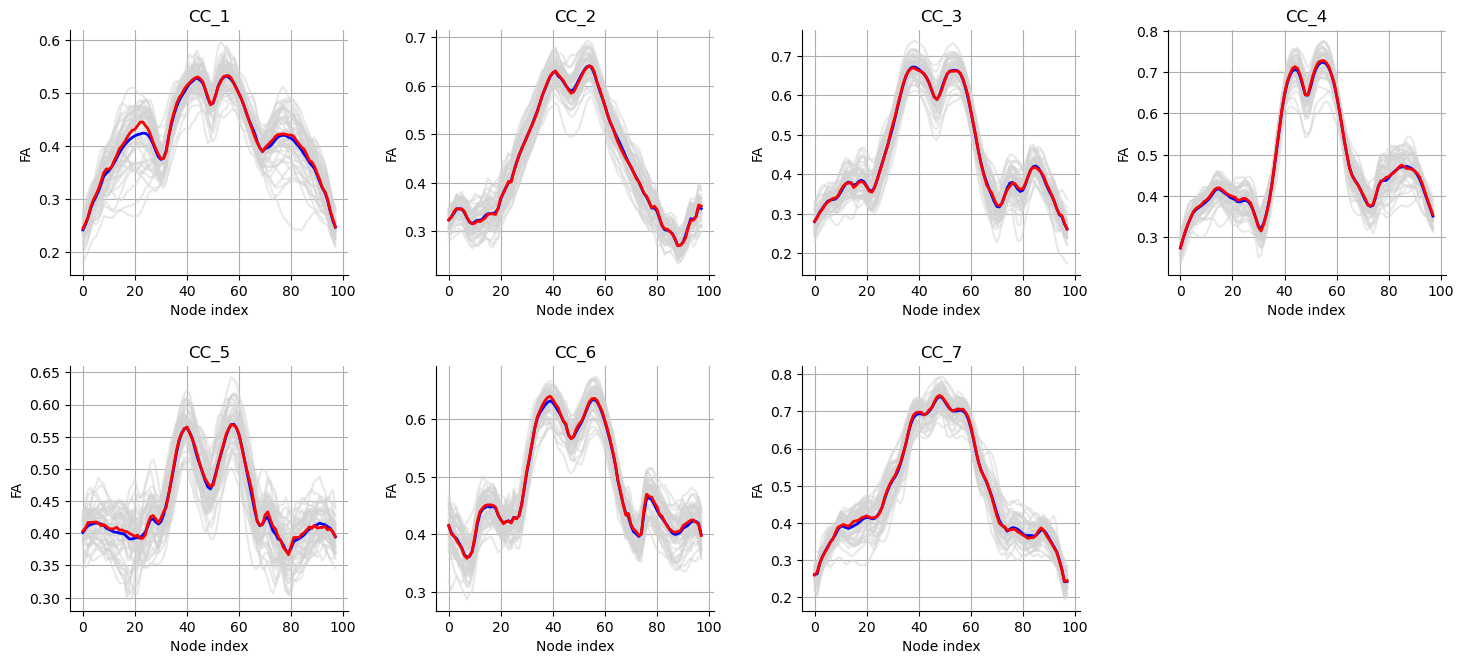

In [132]:
CCx_list = ['CC_1','CC_2','CC_3','CC_4','CC_5','CC_6','CC_7']
fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(15, 7))
axs = axs.flatten()

for i, CCx in enumerate(CCx_list[0:7]):
    file_path = os.path.join(pathcsv, f'{CCx}_FA{addtotitle}.csv')

    axs[i].plot(DTI_all[:,:,i].T, color='lightgray', alpha=0.5)
    axs[i].plot(DTI_all[:,:,i].mean(axis=0), color='blue', linewidth=2)
    axs[i].plot(np.median(DTI_all[:,:,i], axis=0), color='red', linewidth=2)
    axs[i].set_xlabel('Node index')
    axs[i].set_ylabel('FA')
    axs[i].grid(True)
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)
    axs[i].set_title(CCx)
    
fig.delaxes(axs[7])
plt.tight_layout(pad=2.0)



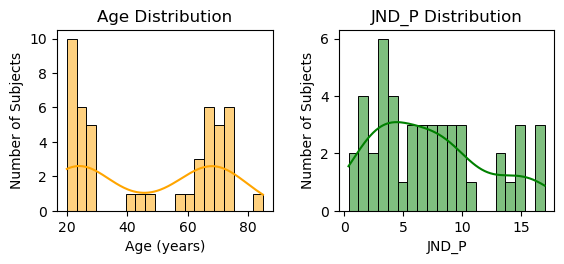

In [133]:
 # target var

import seaborn as sns

age_all = Aging_INDICES['age'].values
jnd_all = Aging_INDICES['JND_P'].values

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(6, 3))
axs = axs.flatten()

sns.histplot(age_all, bins=20, ax=axs[0],color='orange',kde=True)
axs[0].set_title('Age Distribution')
axs[0].set_xlabel('Age (years)')
axs[0].set_ylabel('Number of Subjects')
sns.histplot(jnd_all, bins=20, ax=axs[1],color='green',kde=True)
axs[1].set_title('JND_P Distribution')
axs[1].set_xlabel('JND_P')
axs[1].set_ylabel('Number of Subjects')
plt.tight_layout(pad=2.0)
plt.show()


In [134]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.exceptions import ConvergenceWarning
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, GridSearchCV, learning_curve
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression, SelectFromModel
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import Lasso, Ridge, LassoCV, RidgeCV
from sklearn.pipeline import Pipeline

labels = [0,1]

Aging_INDICES['JND_group'] = pd.qcut(Aging_INDICES['JND_P'], q=2, labels=labels)
age_all_grouped = Aging_INDICES['group_O']
jnd_all_grouped = Aging_INDICES['JND_group']

Aging_INDICES

selection=age_all>0

# age=age_all[selection]
# jnd=jnd_all[selection]
# DTI=DTI_all[selection,:,:]

age=age_all[:42]
jnd=jnd_all[:42]
DTI=DTI_all[:42,:,:]

# scaler = RobustScaler()
# DTI_all_scaled = scaler.fit_transform(DTI.reshape(-1, DTI.shape[-1])).reshape(DTI.shape)

# DTI=DTI_all_scaled
DTI.shape

(42, 98, 7)

Feat selectio based on simple lin regression using f_regression

Feat selection based on simple linear regression using f_regression

CC 1 - Best features for JND: [76 75 77 84 74 85 83 86 82 78]
CC 1 - Best features for Age: [15 14 16 13 17 12 18 74 75 11]
CC 2 - Best features for JND: [13 87 72  7  9 73 70 69 71 86]
CC 2 - Best features for Age: [10 72  9 70 71 12 63 62 83 73]
CC 3 - Best features for JND: [14 13 22 15 23 12 21 24 67 68]
CC 3 - Best features for Age: [42 41 40 23 66 43 14 24 67 22]
CC 4 - Best features for JND: [70 69 71 57 78 56 45 77 79 54]
CC 4 - Best features for Age: [77 78 76 69 70 79  7  6 75 55]
CC 5 - Best features for JND: [74 73 15 16 58 59 42 75 60 72]
CC 5 - Best features for Age: [73 74 72 75 10 11 13 12 88  8]
CC 6 - Best features for JND: [75 84 52 86 85 87 82 83 51 88]
CC 6 - Best features for Age: [82 83 81 84 80 85 79 15 78 86]
CC 7 - Best features for JND: [41 42 53 40 38 43 54 37 39 52]
CC 7 - Best features for Age: [22 24 30 32 23  0 25 31 33 29]


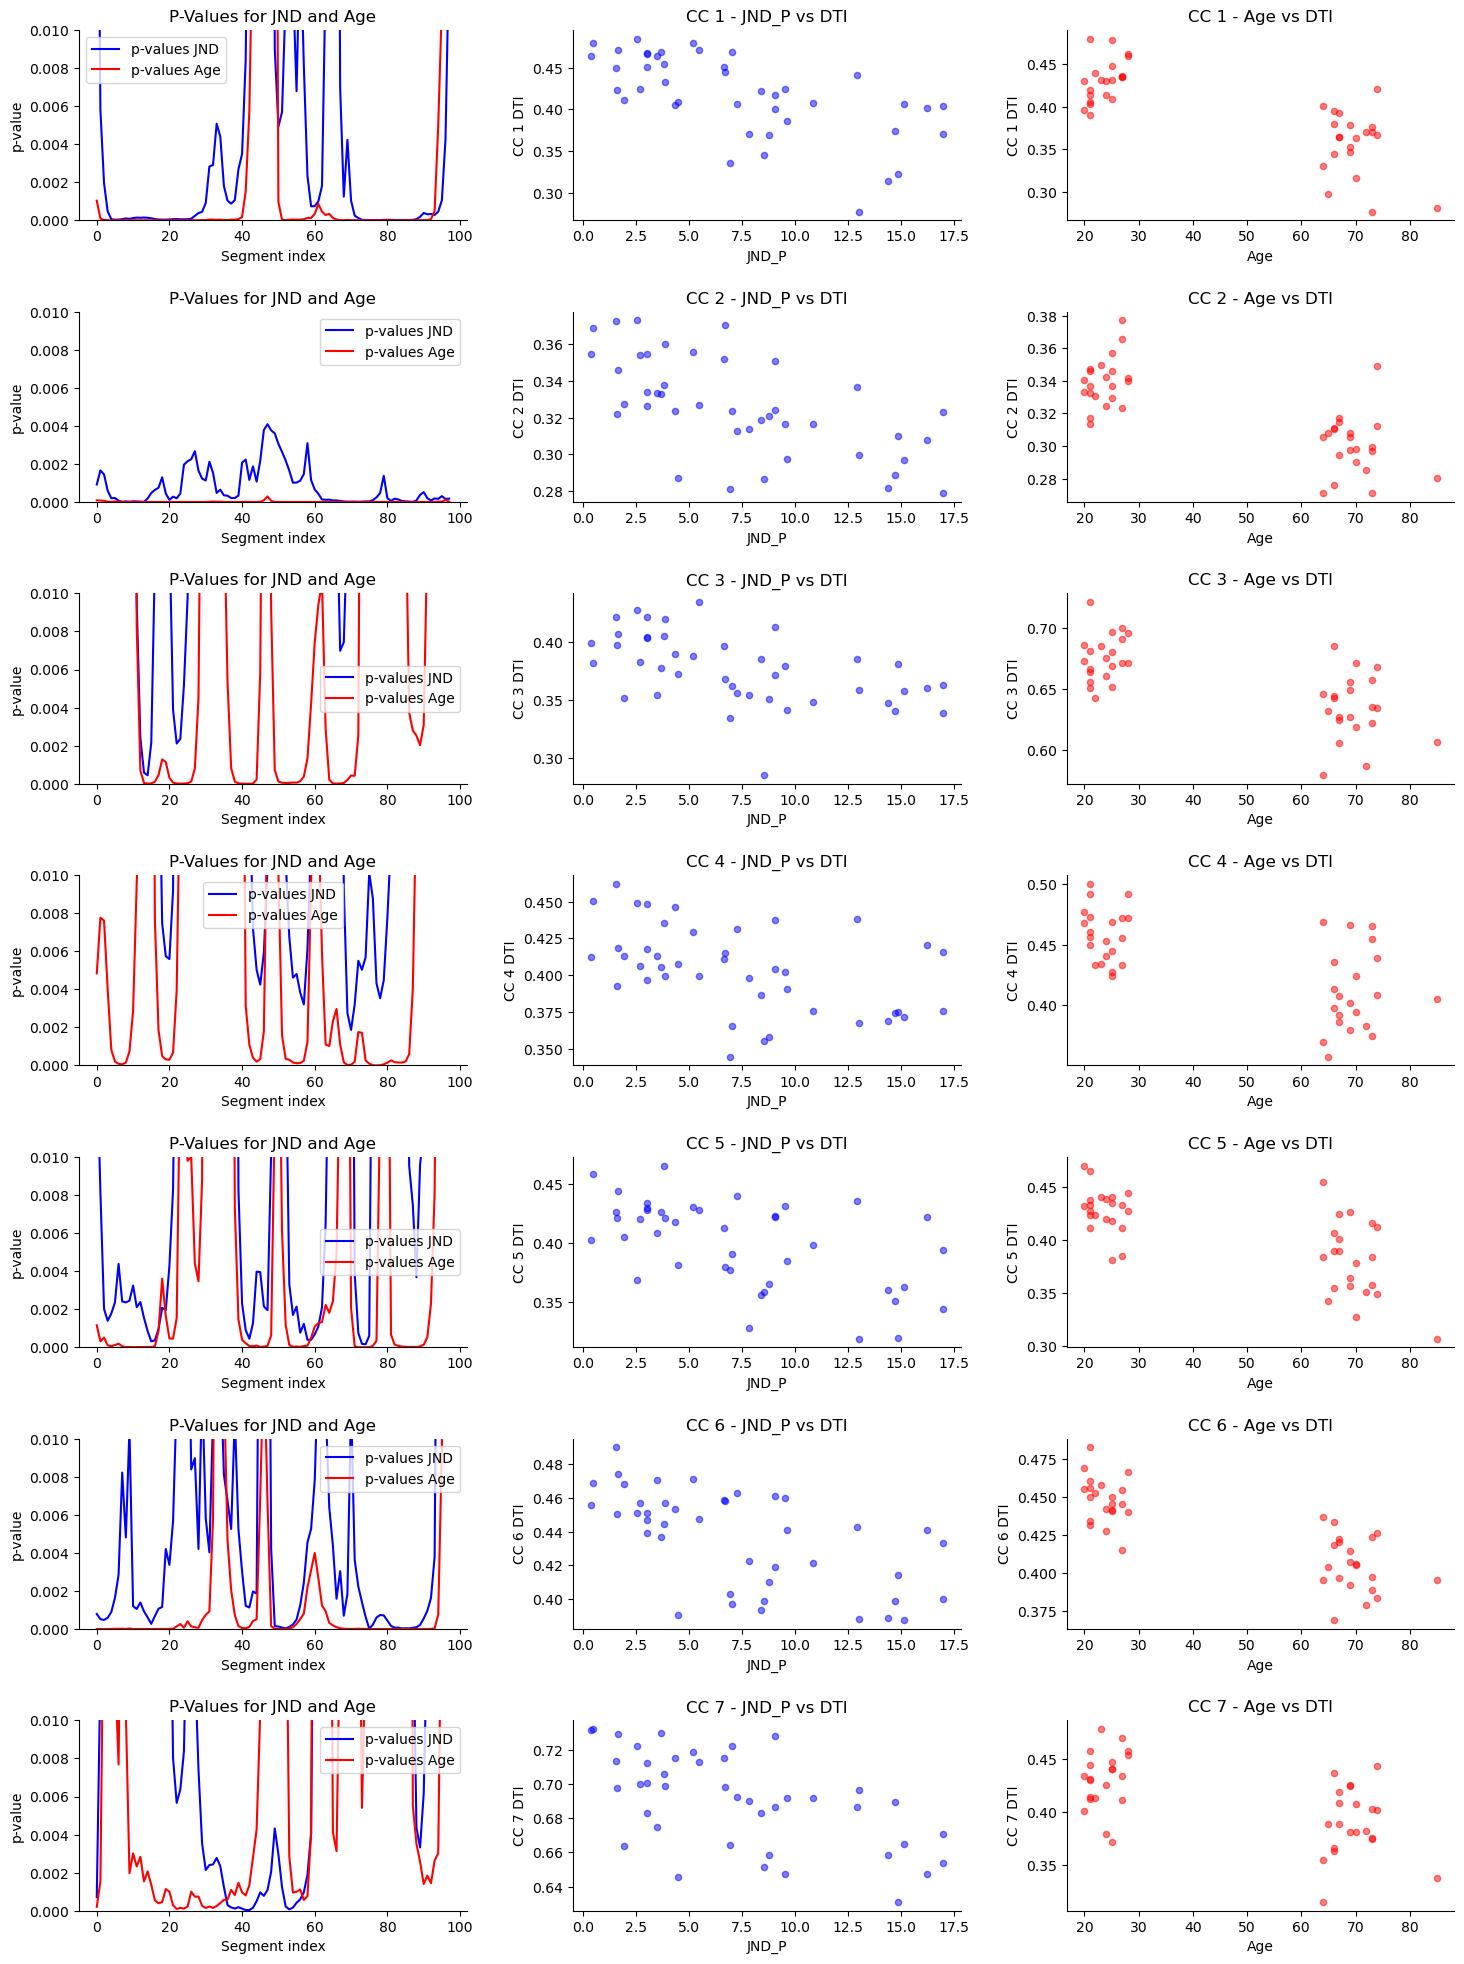

In [135]:
fig, axs = plt.subplots(nrows=7, ncols=3, figsize=(15, 20))

f_reg_best_features_jnd_cc_allCC = np.zeros((7,10), dtype=int)
f_reg_best_features_age_cc_allCC = np.zeros((7,10), dtype=int)

print('Feat selection based on simple linear regression using f_regression\n')

for cc in range(1,8):
        
    f_statistic_jnd, p_values_jnd = f_regression(DTI[:,:,cc-1], jnd )
    f_statistic_age, p_values_age = f_regression(DTI[:,:,cc-1], age )

    f_reg_best_features_jnd_cc = np.argsort(p_values_jnd)[:97]
    f_reg_best_features_age_cc = np.argsort(p_values_age)[:97]
    
    print(f'CC {cc} - Best features for JND: {f_reg_best_features_jnd_cc[:10]}')
    print(f'CC {cc} - Best features for Age: {f_reg_best_features_age_cc[:10]}')

    f_reg_best_features_jnd_cc_allCC[cc-1,:]= f_reg_best_features_jnd_cc[:10]
    f_reg_best_features_age_cc_allCC[cc-1,:] = f_reg_best_features_age_cc[:10]

    axs[cc-1,0].plot(p_values_jnd, color='blue', label='p-values JND')
    axs[cc-1,0].plot(p_values_age, color='red', label='p-values Age')

    axs[cc-1,0].set_ylim(0, 0.01)
    axs[cc-1,0].set_xlabel('Segment index')
    axs[cc-1,0].set_ylabel('p-value')
    axs[cc-1,0].legend()
    axs[cc-1,0].set_title('P-Values for JND and Age')
    axs[cc-1,0].spines['top'].set_visible(False)
    axs[cc-1,0].spines['right'].set_visible(False)


    featn_jnd=f_reg_best_features_jnd_cc[0]  # on prend la feature la plus significative pour JND
    featn_age=f_reg_best_features_age_cc[0]  # on prend la feature la plus significative pour Age

    axs[cc-1,1].scatter(jnd, DTI[:,featn_jnd,cc-1], color='blue', label='Données', alpha=0.5, s=20)
    axs[cc-1,2].scatter(age, DTI[:,featn_age,cc-1], color='red', label='Données', alpha=0.5, s=20)
    axs[cc-1,1].set_xlabel('JND_P')
    axs[cc-1,1].set_ylabel(f'CC {cc} DTI')
    axs[cc-1,2].set_xlabel('Age')
    axs[cc-1,2].set_ylabel(f'CC {cc} DTI')
    axs[cc-1,1].spines['top'].set_visible(False)
    axs[cc-1,2].spines['top'].set_visible(False)
    axs[cc-1,1].spines['right'].set_visible(False)
    axs[cc-1,2].spines['right'].set_visible(False)
    axs[cc-1,1].set_title(f'CC {cc} - JND_P vs DTI')
    axs[cc-1,2].set_title(f'CC {cc} - Age vs DTI')
    
plt.tight_layout(pad=2.0)



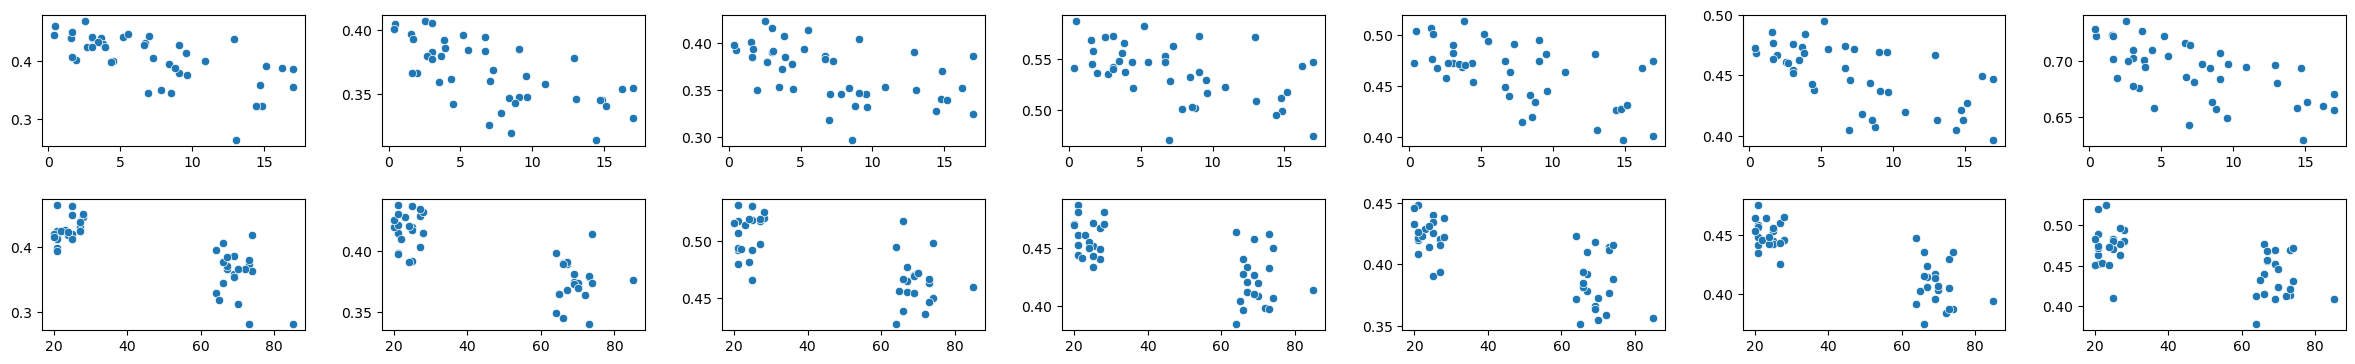

In [136]:
fig,axs = plt.subplots(nrows=2, ncols=7, figsize=(24,4))

for cc in range(7):
    sns.scatterplot(y=DTI[:,f_reg_best_features_jnd_cc_allCC[cc,:].tolist(),cc].mean(axis=1), x=jnd, ax=axs[0,cc]) 
    sns.scatterplot(y=DTI[:,f_reg_best_features_age_cc_allCC[cc,:].tolist(),cc].mean(axis=1), x=age, ax=axs[1,cc])

plt.tight_layout(pad=2.0)

feat selection based on mutual_info_regression

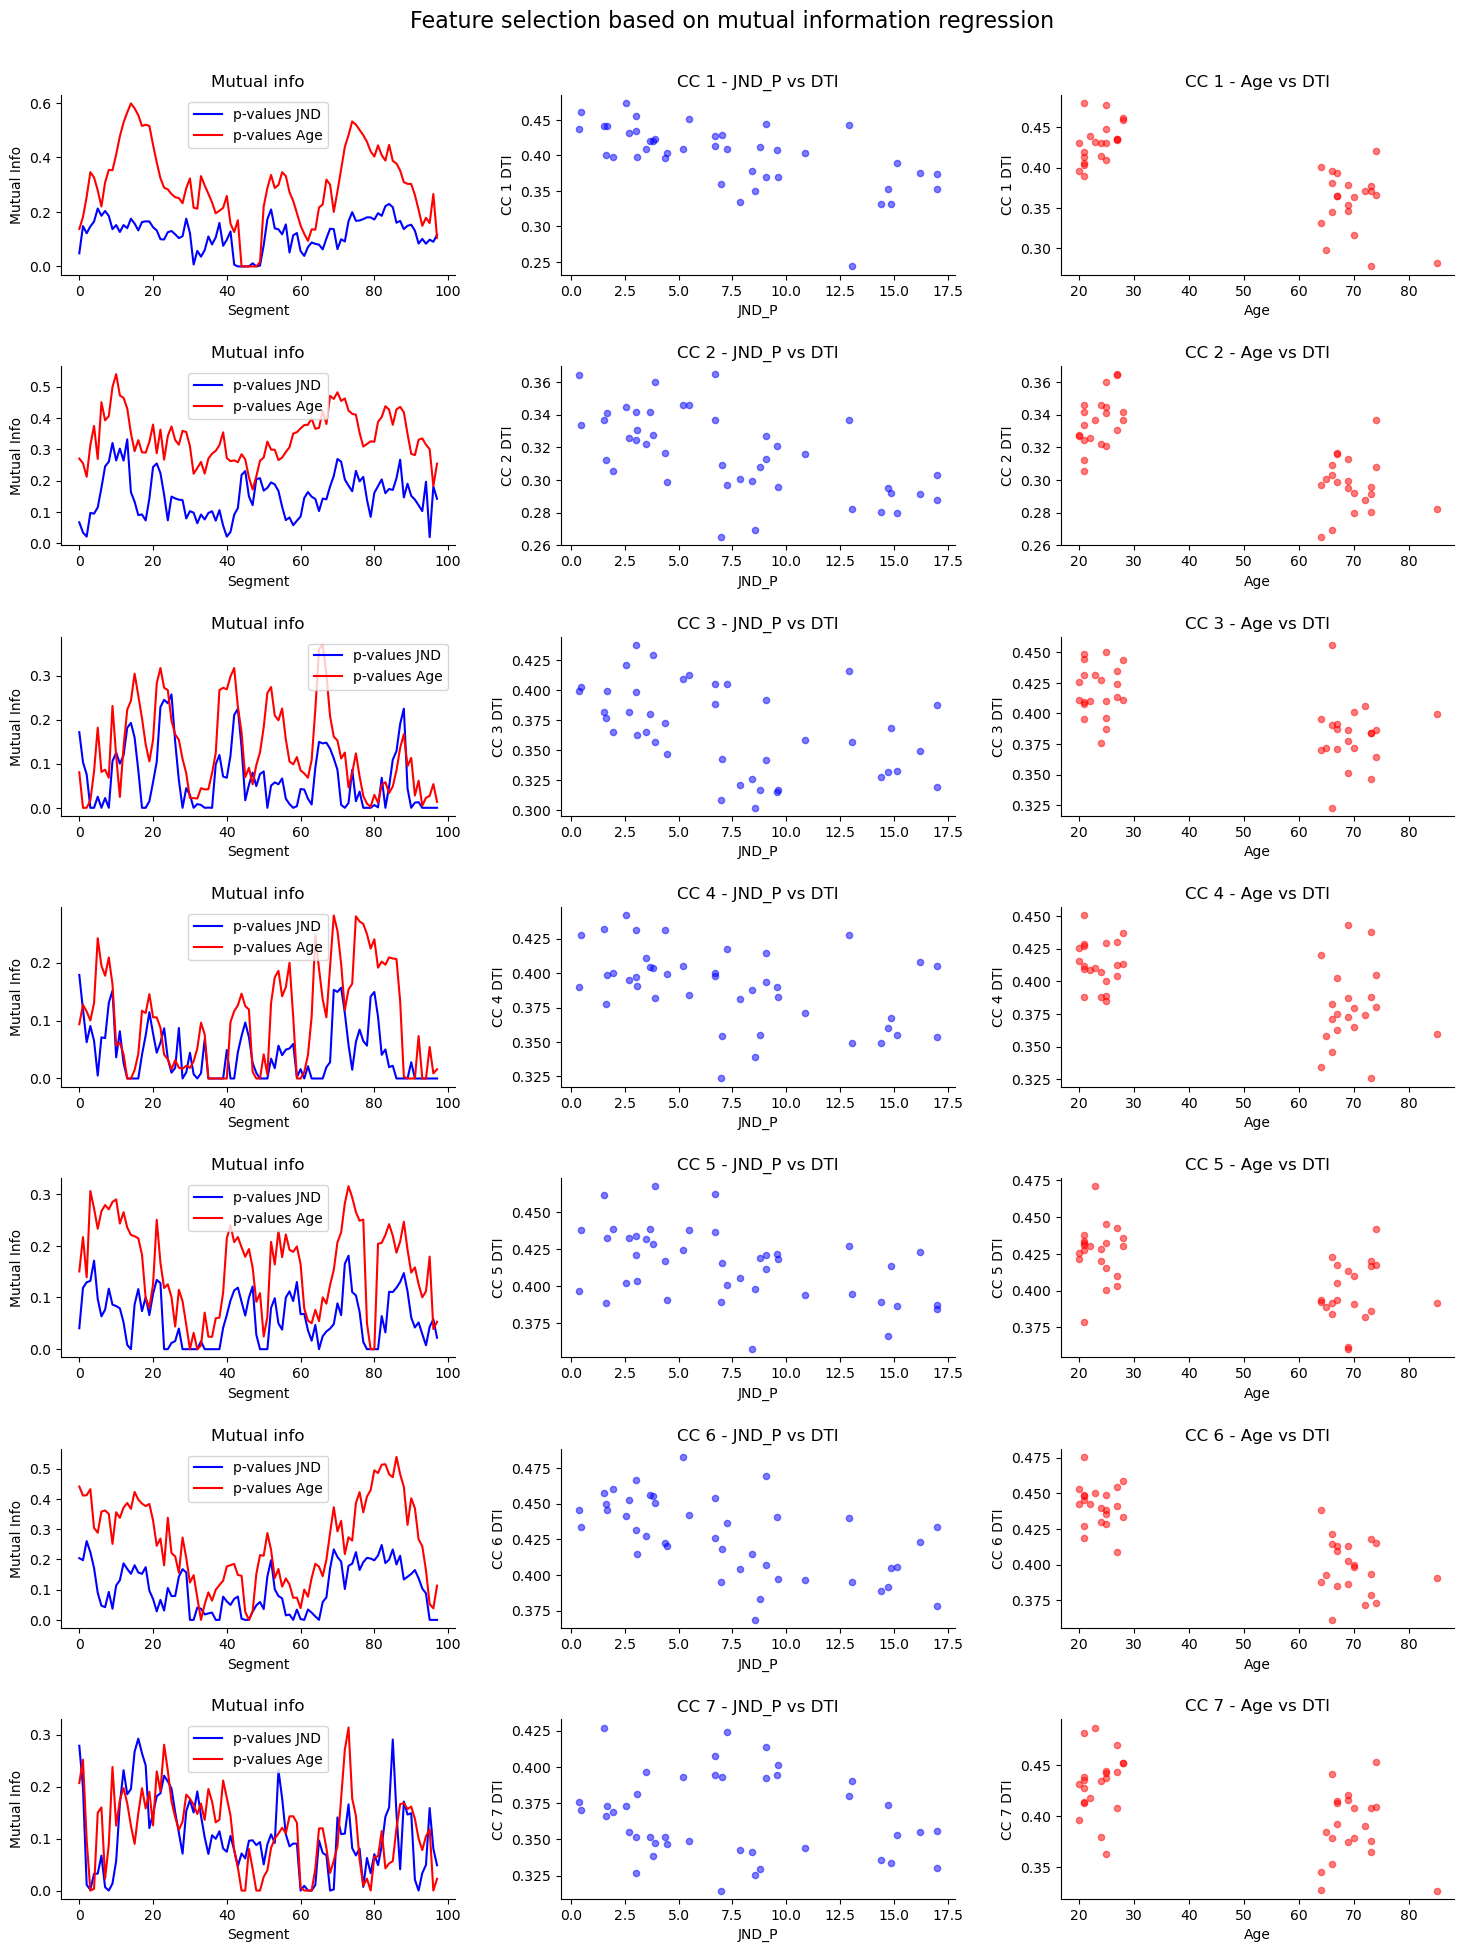

In [137]:
from sklearn.feature_selection import mutual_info_regression

fig, axs = plt.subplots(nrows=7, ncols=3, figsize=(15, 20))

mutual_info_best_features_jnd_cc_allCC = np.zeros((7,10), dtype=int)
mutual_info_best_features_age_cc_allCC = np.zeros((7,10), dtype=int)

mutual_info_age_allcc = np.zeros((7,98))
mutual_info_jnd_allcc = np.zeros((7,98))

for cc in range(1,8):   

    mutual_info_jnd = mutual_info_regression(DTI[:,:,cc-1], jnd, discrete_features=False,n_neighbors=6)
    mutual_info_age = mutual_info_regression(DTI[:,:,cc-1], age, discrete_features=False,n_neighbors=6)

    mutual_info_age_allcc[cc-1,:] = mutual_info_age
    mutual_info_jnd_allcc[cc-1,:] = mutual_info_jnd

    mutual_info_best_features_jnd_cc = np.argsort(mutual_info_jnd)[:97]
    mutual_info_best_features_age_cc = np.argsort(mutual_info_age)[:97]

    mutual_info_best_features_jnd_cc_allCC[cc-1,:]= mutual_info_best_features_jnd_cc[-10:]
    mutual_info_best_features_age_cc_allCC[cc-1,:] = mutual_info_best_features_age_cc[-10:]


    axs[cc-1,0].plot(mutual_info_jnd, color='blue', label='p-values JND')
    axs[cc-1,0].plot(mutual_info_age, color='red', label='p-values Age')

    axs[cc-1,0].set_xlabel('Segment')
    axs[cc-1,0].set_ylabel('Mutual Info')
    axs[cc-1,0].legend()
    axs[cc-1,0].set_title('Mutual info')
    axs[cc-1,0].spines['top'].set_visible(False)
    axs[cc-1,0].spines['right'].set_visible(False)

   
    featn_jnd=mutual_info_best_features_jnd_cc[-1]  # on prend la feature la plus significative pour JND
    featn_age=mutual_info_best_features_age_cc[-1]  # on prend la feature la plus significative pour Age

    axs[cc-1,1].scatter(jnd, DTI[:,featn_jnd,cc-1], color='blue', label='Données', alpha=0.5, s=20)
    axs[cc-1,2].scatter(age, DTI[:,featn_age,cc-1], color='red', label='Données', alpha=0.5, s=20)
    axs[cc-1,1].set_xlabel('JND_P')
    axs[cc-1,1].set_ylabel(f'CC {cc} DTI')
    axs[cc-1,2].set_xlabel('Age')
    axs[cc-1,2].set_ylabel(f'CC {cc} DTI')
    axs[cc-1,1].spines['top'].set_visible(False)
    axs[cc-1,2].spines['top'].set_visible(False)
    axs[cc-1,1].spines['right'].set_visible(False)
    axs[cc-1,2].spines['right'].set_visible(False)
    axs[cc-1,1].set_title(f'CC {cc} - JND_P vs DTI')
    axs[cc-1,2].set_title(f'CC {cc} - Age vs DTI')

fig.suptitle('Feature selection based on mutual information regression\n', fontsize=16)

plt.tight_layout(pad=2.0) 

based on r_regression

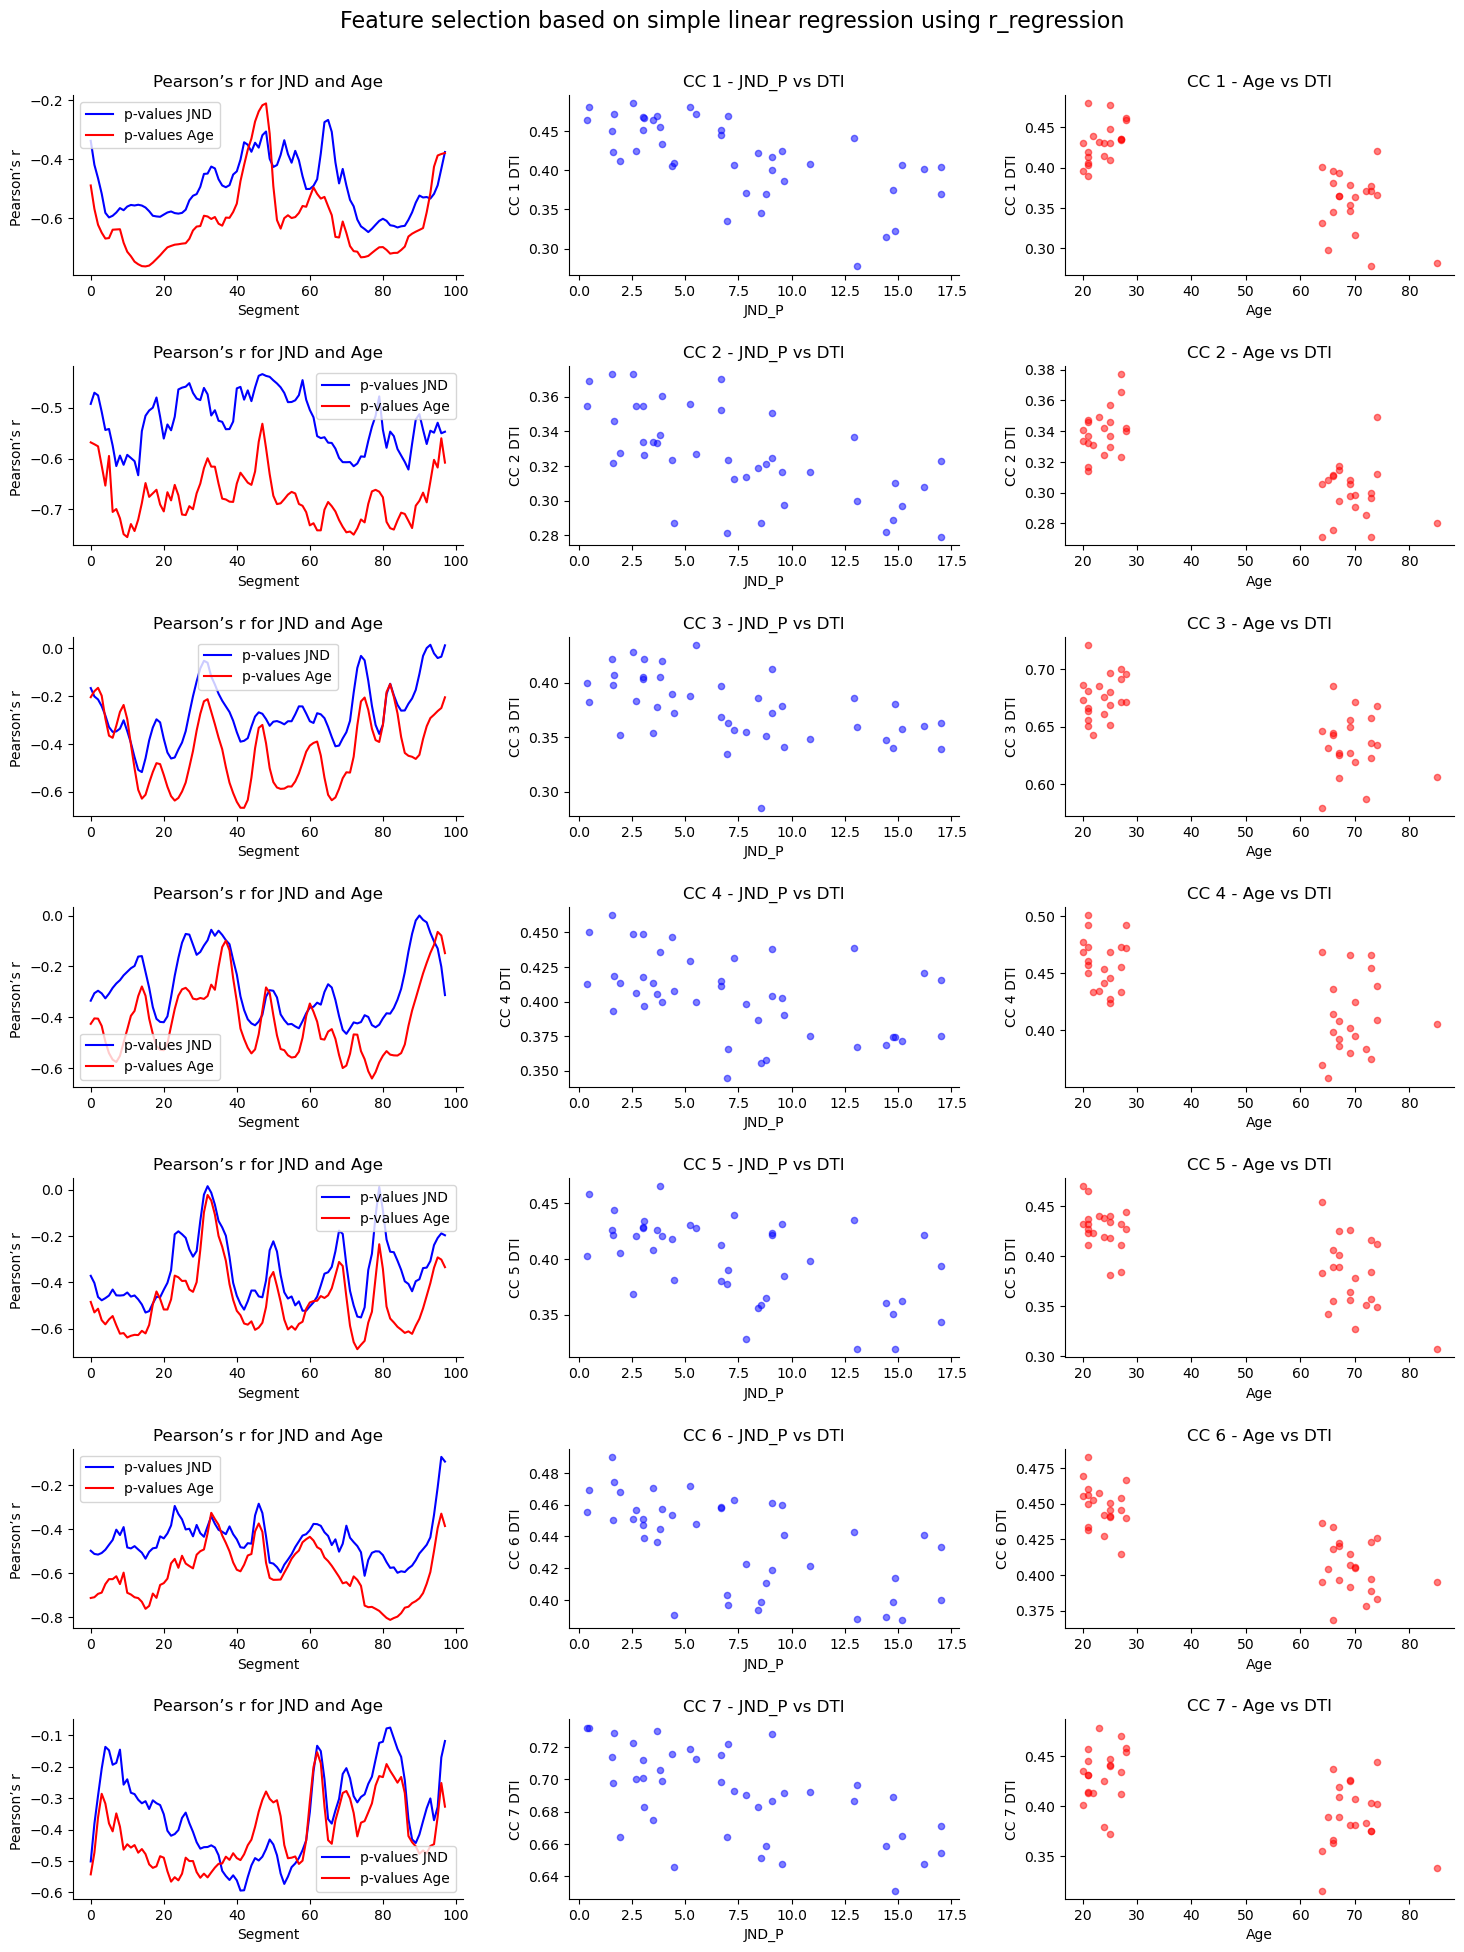

In [138]:
from sklearn.feature_selection import r_regression



r_reg_age_allcc = np.zeros((7,98))
for cc in range(1,8):   

    r_reg_jnd = r_regression(DTI[:,:,cc-1], jnd)
    r_reg_age = r_regression(DTI[:,:,cc-1], age)

    r_reg_age_allcc[cc-1,:] = r_reg_age


    axs[cc-1,0].plot(r_reg_jnd, color='blue', label='p-values JND')
    axs[cc-1,0].plot(r_reg_age, color='red', label='p-values Age')

    axs[cc-1,0].set_xlabel('Segment')
    axs[cc-1,0].set_ylabel('R reg Info')
    axs[cc-1,0].legend()
    axs[cc-1,0].set_title('R reg info')
    axs[cc-1,0].spines['top'].set_visible(False)
    axs[cc-1,0].spines['right'].set_visible(False)



####

from sklearn.feature_selection import r_regression

fig, axs = plt.subplots(nrows=7, ncols=3, figsize=(15, 20))

r_reg_best_features_jnd_cc_allCC = np.zeros((7,10), dtype=int)
r_reg_best_features_age_cc_allCC = np.zeros((7,10), dtype=int)

r_reg_age_allcc = np.zeros((7,98))
for cc in range(1,8):   

    r_reg_jnd = r_regression(DTI[:,:,cc-1], jnd)
    r_reg_age = r_regression(DTI[:,:,cc-1], age)

    r_reg_age_allcc[cc-1,:] = r_reg_age
    
    r_reg_best_features_jnd_cc = np.argsort(r_reg_jnd)[:97]
    r_reg_best_features_age_cc = np.argsort(r_reg_age)[:97]

    r_reg_best_features_jnd_cc_allCC[cc-1,:]= r_reg_best_features_jnd_cc[:10]
    r_reg_best_features_age_cc_allCC[cc-1,:] = r_reg_best_features_age_cc[:10]


    axs[cc-1,0].plot(r_reg_jnd, color='blue', label='p-values JND')
    axs[cc-1,0].plot(r_reg_age, color='red', label='p-values Age')

    axs[cc-1,0].set_xlabel('Segment')
    axs[cc-1,0].set_ylabel('Pearson’s r ')
    axs[cc-1,0].legend()
    axs[cc-1,0].set_title('Pearson’s r for JND and Age')
    axs[cc-1,0].spines['top'].set_visible(False)
    axs[cc-1,0].spines['right'].set_visible(False)

   
    featn_jnd=r_reg_best_features_jnd_cc[0]  # on prend la feature la plus significative pour JND
    featn_age=r_reg_best_features_age_cc[0]  # on prend la feature la plus significative pour Age

    axs[cc-1,1].scatter(jnd, DTI[:,featn_jnd,cc-1], color='blue', label='Données', alpha=0.5, s=20)
    axs[cc-1,2].scatter(age, DTI[:,featn_age,cc-1], color='red', label='Données', alpha=0.5, s=20)
    axs[cc-1,1].set_xlabel('JND_P')
    axs[cc-1,1].set_ylabel(f'CC {cc} DTI')
    axs[cc-1,2].set_xlabel('Age')
    axs[cc-1,2].set_ylabel(f'CC {cc} DTI')
    axs[cc-1,1].spines['top'].set_visible(False)
    axs[cc-1,2].spines['top'].set_visible(False)
    axs[cc-1,1].spines['right'].set_visible(False)
    axs[cc-1,2].spines['right'].set_visible(False)
    axs[cc-1,1].set_title(f'CC {cc} - JND_P vs DTI')
    axs[cc-1,2].set_title(f'CC {cc} - Age vs DTI')

fig.suptitle('Feature selection based on simple linear regression using r_regression\n', fontsize=16)
    
plt.tight_layout(pad=2.0) 

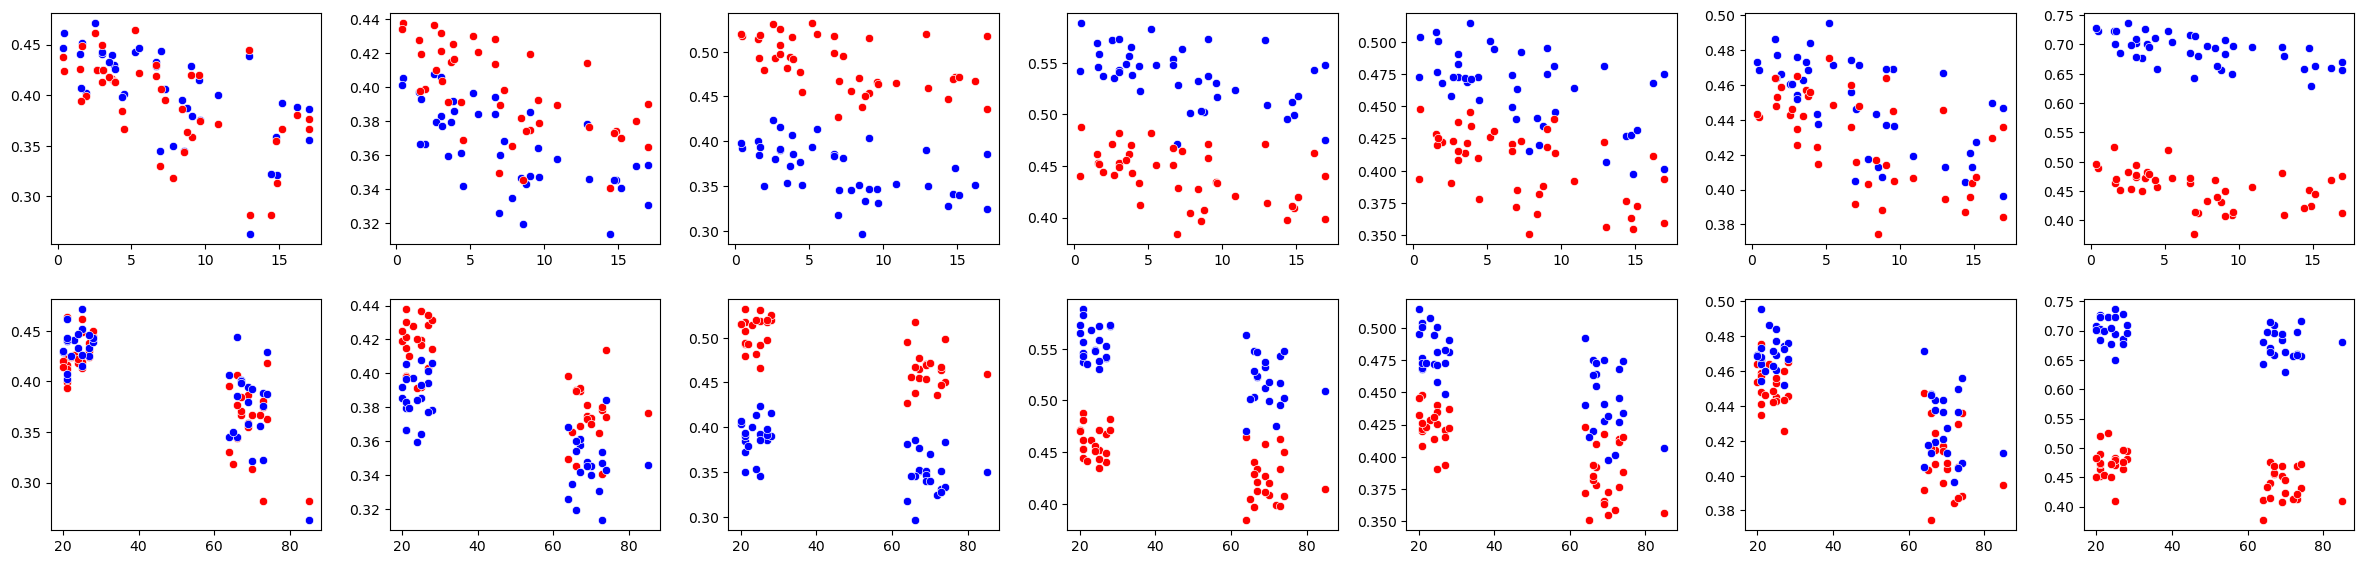

In [142]:
fig,axs = plt.subplots(nrows=2, ncols=7, figsize=(24,6))

for cc in range(7):
    sns.scatterplot(y=DTI[:,r_reg_best_features_jnd_cc_allCC[cc,:].tolist(),cc].mean(axis=1), x=jnd, ax=axs[0,cc], color='blue')
    sns.scatterplot(y=DTI[:,r_reg_best_features_age_cc_allCC[cc,:].tolist(),cc].mean(axis=1), x=jnd, ax=axs[0,cc], color='red') 

    sns.scatterplot(y=DTI[:,r_reg_best_features_age_cc_allCC[cc,:].tolist(),cc].mean(axis=1), x=age, ax=axs[1,cc], color='red')
    sns.scatterplot(y=DTI[:,r_reg_best_features_jnd_cc_allCC[cc,:].tolist(),cc].mean(axis=1), x=age, ax=axs[1,cc], color='blue')
    
plt.tight_layout(pad=2.0)